# Notebook 04 — Escolha dos Algoritmos
## Step 3: Choose a Model — ML Life Cycle

> **Objetivo:** Antes de treinar qualquer modelo, documentar a justificativa de escolha de cada algoritmo candidato.  
> Isso demonstra entendimento do problema e é avaliado no relatório técnico.

---

**Dependência:** Este notebook pressupõe que os notebooks anteriores já foram executados:
- `01_coleta_dados.ipynb` → dataset disponível em `data/tabular/`
- `02_eda.ipynb` → distribuição, balanceamento e correlações conhecidos
- `03_preprocessamento.ipynb` → splits `X_train`, `X_val`, `X_test` e `scaler.pkl` gerados

In [1]:
# Importações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

---
## 1. Caracterização do Problema

Antes de escolher qualquer algoritmo, é fundamental entender as características do problema.  
Cada dimensão abaixo restringe ou favorece determinados algoritmos.

In [2]:
# Carregar splits para inspecionar características
X_train = pd.read_csv('../data/tabular/X_train.csv')
X_val   = pd.read_csv('../data/tabular/X_val.csv')
X_test  = pd.read_csv('../data/tabular/X_test.csv')
y_train = pd.read_csv('../data/tabular/y_train.csv').squeeze()
y_val   = pd.read_csv('../data/tabular/y_val.csv').squeeze()
y_test  = pd.read_csv('../data/tabular/y_test.csv').squeeze()

n_total = len(X_train) + len(X_val) + len(X_test)
n_classes = y_train.nunique()
classes = y_train.unique().tolist()

print(f"Total de registros : {n_total}")
print(f"Treino             : {len(X_train)} ({len(X_train)/n_total*100:.0f}%)")
print(f"Validação          : {len(X_val)} ({len(X_val)/n_total*100:.0f}%)")
print(f"Teste              : {len(X_test)} ({len(X_test)/n_total*100:.0f}%)")
print(f"\nFeatures           : {X_train.shape[1]}")
print(f"Classes            : {n_classes} → {classes}")
print()
print("Distribuição das classes (treino):")
print(y_train.value_counts().to_string())

Total de registros : 1500
Treino             : 1050 (70%)
Validação          : 225 (15%)
Teste              : 225 (15%)

Features           : 9
Classes            : 3 → ['pneumonia', 'pulmonary edema', 'atelectasis']

Distribuição das classes (treino):
true_label
pneumonia          350
pulmonary edema    350
atelectasis        350


In [3]:
# Caracterizar o problema de forma estruturada
problema = pd.DataFrame([
    {
        'Dimensão': 'Tipo de tarefa',
        'Valor': 'Classificação multiclasse (3 classes)',
        'Impacto na escolha do algoritmo': 'Todos os candidatos suportam multiclasse nativamente ou via estratégia OvR/OvO'
    },
    {
        'Dimensão': 'Classes alvo',
        'Valor': 'pneumonia / pulmonary edema / atelectasis',
        'Impacto na escolha do algoritmo': 'Diagnóstico diferencial — errar entre doenças distintas tem consequências clínicas'
    },
    {
        'Dimensão': 'Tamanho do dataset',
        'Valor': f'{n_total} registros',
        'Impacto na escolha do algoritmo': 'Dataset pequeno/médio — não justifica redes neurais profundas para dados tabulares'
    },
    {
        'Dimensão': 'Balanceamento',
        'Valor': 'Perfeitamente balanceado (500 por classe)',
        'Impacto na escolha do algoritmo': 'Não exige class_weight nem técnicas de SMOTE — Accuracy é métrica válida aqui'
    },
    {
        'Dimensão': 'Tipo das features',
        'Valor': 'Mistas: binárias (0/1) e contínuas',
        'Impacto na escolha do algoritmo': 'Algoritmos baseados em distância (KNN) precisam de escalonamento; baseados em árvore, não'
    },
    {
        'Dimensão': 'Número de features',
        'Valor': f'{X_train.shape[1]} features após pré-processamento',
        'Impacto na escolha do algoritmo': 'Baixa dimensionalidade — KNN e Reg. Logística funcionam bem; sem maldição da dimensionalidade'
    },
    {
        'Dimensão': 'Interpretabilidade',
        'Valor': 'Alta — área médica exige explicação da decisão',
        'Impacto na escolha do algoritmo': 'Preferir modelos que oferecem feature importance ou coeficientes interpretáveis'
    },
    {
        'Dimensão': 'Tempo de inferência',
        'Valor': 'Baixo — uso em triagem clínica, deve ser rápido',
        'Impacto na escolha do algoritmo': 'Descartar modelos muito lentos em produção; KNN sofre com datasets maiores'
    },
])

print("=== CARACTERIZAÇÃO DO PROBLEMA ===")
print(problema.to_string(index=False))

=== CARACTERIZAÇÃO DO PROBLEMA ===
           Dimensão                                           Valor                                                               Impacto na escolha do algoritmo
     Tipo de tarefa           Classificação multiclasse (3 classes)                Todos os candidatos suportam multiclasse nativamente ou via estratégia OvR/OvO
       Classes alvo       pneumonia / pulmonary edema / atelectasis            Diagnóstico diferencial — errar entre doenças distintas tem consequências clínicas
 Tamanho do dataset                                  1500 registros            Dataset pequeno/médio — não justifica redes neurais profundas para dados tabulares
      Balanceamento       Perfeitamente balanceado (500 por classe)                 Não exige class_weight nem técnicas de SMOTE — Accuracy é métrica válida aqui
  Tipo das features              Mistas: binárias (0/1) e contínuas     Algoritmos baseados em distância (KNN) precisam de escalonamento; baseados em árvor

### Análise das características do problema

O problema apresenta características que **restringem e orientam** a escolha dos algoritmos:

1. **Classificação multiclasse com 3 classes** — o modelo precisa distinguir pneumonia de edema pulmonar e atelectasia simultaneamente. Erro entre classes tem impacto clínico direto: tratamentos são diferentes para cada condição.

2. **Dataset pequeno e perfeitamente balanceado** — com apenas 1.500 registros e distribuição perfeita (500/classe), algoritmos simples podem performar muito bem. Não há necessidade de técnicas de rebalanceamento nem de arquiteturas complexas.

3. **Features mistas: binárias e contínuas** — a combinação de variáveis booleanas (fever, tachycardia, crackles, resultados de raio-X) com contínuas (oxygen_saturation, wbc_count) favorece algoritmos não paramétricos como árvores, que não assumem forma funcional das relações.

4. **Interpretabilidade é requisito** — em ambiente clínico, o médico precisa entender *por que* o modelo chegou àquela conclusão. Isso favorece Árvores de Decisão e Regressão Logística (coeficientes diretos), e Random Forest com feature importance.

---
## 2. Algoritmos Candidatos — Tabela de Adequação

In [4]:
# Tabela de adequação dos algoritmos ao problema
algoritmos = pd.DataFrame([
    {
        'Algoritmo': 'Regressão Logística',
        'Paradigma': 'Linear / Probabilístico',
        'Multiclasse': 'Sim (OvR nativo)',
        'Vantagens': 'Altamente interpretável (coeficientes); probabilidades calibradas; rápido em treino e inferência',
        'Desvantagens': 'Assume linearidade entre features e log-odds; pode não capturar relações não-lineares entre sintomas',
        'Precisa escalar?': 'Sim',
        'Adequado ao problema?': '✅ Sim — excelente baseline e muito interpretável para uso médico'
    },
    {
        'Algoritmo': 'Árvore de Decisão',
        'Paradigma': 'Baseado em regras',
        'Multiclasse': 'Sim (nativo)',
        'Vantagens': 'Visualizável (médico consegue ler as regras); captura não-linearidades; não requer escalonamento',
        'Desvantagens': 'Propensa a overfitting sem limitação de profundidade (max_depth); instável — pequenas mudanças nos dados alteram muito a árvore',
        'Precisa escalar?': 'Não',
        'Adequado ao problema?': '✅ Sim — regras explícitas são ideais para contexto médico; usar max_depth para controlar overfitting'
    },
    {
        'Algoritmo': 'Random Forest',
        'Paradigma': 'Ensemble de árvores',
        'Multiclasse': 'Sim (nativo)',
        'Vantagens': 'Robusto ao overfitting; feature importance nativa; captura interações complexas entre sintomas; estável',
        'Desvantagens': 'Menos interpretável individualmente que uma árvore única; mais lento que modelos simples',
        'Precisa escalar?': 'Não',
        'Adequado ao problema?': '✅ Sim — geralmente melhor performance; feature importance alinha com requisito de interpretabilidade'
    },
    {
        'Algoritmo': 'KNN',
        'Paradigma': 'Baseado em instâncias / distância',
        'Multiclasse': 'Sim (nativo)',
        'Vantagens': 'Simples, não paramétrico, intuitivo; sem fase de treino explícita',
        'Desvantagens': 'Lento em inferência (O(n) por predição); sensível a escala e dimensionalidade; sem interpretabilidade direta',
        'Precisa escalar?': 'Sim',
        'Adequado ao problema?': '⚠️ Parcialmente — útil como referência de comparação; sem interpretabilidade direta para uso clínico'
    },
])

# Exibir com formatação
colunas_exibir = ['Algoritmo', 'Paradigma', 'Multiclasse', 'Precisa escalar?', 'Adequado ao problema?']
print("=== TABELA DE ADEQUAÇÃO — VISÃO RESUMIDA ===")
print(algoritmos[colunas_exibir].to_string(index=False))
print()
print("=== DETALHAMENTO: VANTAGENS E DESVANTAGENS ===")
for _, row in algoritmos.iterrows():
    print(f"\n{'─'*60}")
    print(f"  {row['Algoritmo']}")
    print(f"  + {row['Vantagens']}")
    print(f"  - {row['Desvantagens']}")
    print(f"  → {row['Adequado ao problema?']}")

=== TABELA DE ADEQUAÇÃO — VISÃO RESUMIDA ===
          Algoritmo                         Paradigma      Multiclasse Precisa escalar?                                                                                Adequado ao problema?
Regressão Logística           Linear / Probabilístico Sim (OvR nativo)              Sim                                     ✅ Sim — excelente baseline e muito interpretável para uso médico
  Árvore de Decisão                 Baseado em regras     Sim (nativo)              Não ✅ Sim — regras explícitas são ideais para contexto médico; usar max_depth para controlar overfitting
      Random Forest               Ensemble de árvores     Sim (nativo)              Não ✅ Sim — geralmente melhor performance; feature importance alinha com requisito de interpretabilidade
                KNN Baseado em instâncias / distância     Sim (nativo)              Sim ⚠️ Parcialmente — útil como referência de comparação; sem interpretabilidade direta para uso clínico

=== DETAL

### Justificativa de cada algoritmo

#### Regressão Logística
Escolhida como **baseline** obrigatório. Em diagnóstico diferencial, a interpretação dos coeficientes é direta: coeficiente positivo alto para `crackles` na classe `pneumonia` significa que esse sintoma aumenta diretamente a probabilidade dessa classe. Médicos conseguem validar se o modelo aprendeu relações clinicamente coerentes. Exige escalonamento porque os coeficientes são sensíveis à magnitude das features.

#### Árvore de Decisão
O único modelo que pode ser **literalmente lido** pelo médico como uma árvore de decisão clínica — "se febre E estertores E saturação < 95% → pneumonia". Esse alinhamento com raciocínio médico é um diferencial importante. A limitação de profundidade (`max_depth`) é essencial para evitar overfitting com apenas 1.500 registros.

#### Random Forest
Esperado como o **melhor modelo em performance** neste problema. Ao combinar múltiplas árvores com amostras e features aleatórias, reduz a variância sem aumentar muito o viés. A feature importance agregada permite saber quais sintomas e exames mais contribuem para o diagnóstico diferencial — informação valiosa para validação clínica e para o relatório.

#### KNN
Incluído para completar a comparação metodológica. Com apenas 9 features e dataset balanceado, não deve sofrer com a maldição da dimensionalidade. Porém, a ausência de interpretabilidade intrínseca e a latência O(n) em inferência limitam seu uso clínico real. É um bom **espelho de comparação**: se Random Forest não performar melhor que KNN, algo está errado.

---
## 3. Critérios de Avaliação — Definidos ANTES do Treino

> ⚠️ **Regra fundamental em ML:** os critérios de avaliação devem ser definidos *antes* de ver qualquer resultado de treinamento, para evitar viés de confirmação na escolha do modelo.

In [5]:
# Critérios de avaliação pré-definidos
criterios = pd.DataFrame([
    {
        'Prioridade': '1ª (principal)',
        'Métrica': 'Recall macro',
        'Justificativa': 'Minimizar Falsos Negativos em todas as classes — errar dizendo que não tem a doença quando tem é o pior erro clínico',
        'Cálculo': 'Média do Recall por classe (sem peso por tamanho — dataset balanceado)'
    },
    {
        'Prioridade': '2ª (secundária)',
        'Métrica': 'F1-score macro',
        'Justificativa': 'Equilíbrio entre Precision e Recall — evita modelo que maximiza Recall às custas de muitos Falsos Positivos',
        'Cálculo': 'Média harmônica de Precision e Recall por classe'
    },
    {
        'Prioridade': '3ª (desempate)',
        'Métrica': 'Accuracy',
        'Justificativa': 'Válida porque o dataset é perfeitamente balanceado — representa proporção de acertos globais',
        'Cálculo': 'Acertos totais / Total de predições'
    },
    {
        'Prioridade': '4ª (qualitativa)',
        'Métrica': 'Interpretabilidade',
        'Justificativa': 'Em caso de empate numérico, priorizar o modelo que o médico consegue entender e validar clinicamente',
        'Cálculo': 'Avaliação qualitativa: coeficientes / regras visuais / feature importance'
    },
])

print("=== CRITÉRIOS DE AVALIAÇÃO ===")
for _, row in criterios.iterrows():
    print(f"\n  {row['Prioridade']}: {row['Métrica']}")
    print(f"  Justificativa : {row['Justificativa']}")
    print(f"  Como calcular : {row['Cálculo']}")

=== CRITÉRIOS DE AVALIAÇÃO ===

  1ª (principal): Recall macro
  Justificativa : Minimizar Falsos Negativos em todas as classes — errar dizendo que não tem a doença quando tem é o pior erro clínico
  Como calcular : Média do Recall por classe (sem peso por tamanho — dataset balanceado)

  2ª (secundária): F1-score macro
  Justificativa : Equilíbrio entre Precision e Recall — evita modelo que maximiza Recall às custas de muitos Falsos Positivos
  Como calcular : Média harmônica de Precision e Recall por classe

  3ª (desempate): Accuracy
  Justificativa : Válida porque o dataset é perfeitamente balanceado — representa proporção de acertos globais
  Como calcular : Acertos totais / Total de predições

  4ª (qualitativa): Interpretabilidade
  Justificativa : Em caso de empate numérico, priorizar o modelo que o médico consegue entender e validar clinicamente
  Como calcular : Avaliação qualitativa: coeficientes / regras visuais / feature importance


### Por que Recall macro e não Accuracy?

Mesmo com dataset balanceado (onde Accuracy seria válida), **Recall é prioritário** neste contexto porque:

- **Falso Negativo = risco clínico direto.** Um modelo que diz "sem pneumonia" para um paciente com pneumonia pode resultar em não-tratamento e agravamento do quadro.
- **O custo assimétrico dos erros** favorece Recall sobre Precision: é preferível encaminhar um paciente saudável para exames adicionais (Falso Positivo) do que liberar um paciente doente sem tratamento (Falso Negativo).
- **Multiclasse:** Recall macro garante que o modelo performa bem em *todas as classes*, não apenas na mais frequente — crítico em diagnóstico diferencial onde confundir pneumonia com atelectasia tem implicações terapêuticas distintas.

O F1-score macro como métrica secundária serve de freio: impede que o modelo maximize Recall artificialmente ao classificar tudo como positivo (recall = 1.0 mas precision = 1/3).

---
## 4. Hipótese Inicial — Qual Algoritmo Deve Performar Melhor?

> Esta é a hipótese *antes* de ver qualquer resultado de treino. Documentar a hipótese inicial e depois compará-la com os resultados reais é uma prática científica essencial em ML.

In [6]:
# Hipótese inicial documentada antes do treinamento
hipotese = {
    'modelo_esperado_vencedor': 'Random Forest',
    'razao_principal': (
        "O dataset combina features binárias (sintomas clínicos: fever, tachycardia, crackles) "
        "com features contínuas (oxygen_saturation, wbc_count) e features derivadas de raio-X. "
        "Essa mistura de tipos, junto com possíveis interações entre sintomas (ex.: febre + estertores + "
        "saturação baixa), favorece modelos baseados em árvores. "
        "O Random Forest captura essas interações sem assumir linearidade, e é mais estável "
        "que uma árvore única."
    ),
    'segundo_colocado_esperado': 'Árvore de Decisão (com max_depth ajustado)',
    'razao_segundo': (
        "Com profundidade controlada, a árvore individual pode capturar as relações chave. "
        "Com apenas 9 features, a árvore não deve sofrer muito com overfitting."
    ),
    'expectativa_regressao_logistica': (
        "Performance moderada — se os sintomas tiverem relações predominantemente lineares com o diagnóstico, "
        "pode surpreender. Caso contrário, ficará atrás dos modelos baseados em árvore."
    ),
    'expectativa_knn': (
        "Performance próxima ou abaixo da Regressão Logística. "
        "Com 9 features binárias/contínuas, a distância euclidiana pode não ser a mais informativa."
    ),
    'metrica_de_validacao_da_hipotese': 'Recall macro no conjunto de validação (notebook 05_treinamento.ipynb)',
}

print("=== HIPÓTESE INICIAL (registrada em:", pd.Timestamp.now().strftime('%Y-%m-%d'), "===")
for chave, valor in hipotese.items():
    print(f"\n  {chave.upper().replace('_', ' ')}:")
    print(f"  {valor}")

=== HIPÓTESE INICIAL (registrada em: 2026-05-19 ===

  MODELO ESPERADO VENCEDOR:
  Random Forest

  RAZAO PRINCIPAL:
  O dataset combina features binárias (sintomas clínicos: fever, tachycardia, crackles) com features contínuas (oxygen_saturation, wbc_count) e features derivadas de raio-X. Essa mistura de tipos, junto com possíveis interações entre sintomas (ex.: febre + estertores + saturação baixa), favorece modelos baseados em árvores. O Random Forest captura essas interações sem assumir linearidade, e é mais estável que uma árvore única.

  SEGUNDO COLOCADO ESPERADO:
  Árvore de Decisão (com max_depth ajustado)

  RAZAO SEGUNDO:
  Com profundidade controlada, a árvore individual pode capturar as relações chave. Com apenas 9 features, a árvore não deve sofrer muito com overfitting.

  EXPECTATIVA REGRESSAO LOGISTICA:
  Performance moderada — se os sintomas tiverem relações predominantemente lineares com o diagnóstico, pode surpreender. Caso contrário, ficará atrás dos modelos basead

### Raciocínio clínico por trás da hipótese

Em diagnóstico diferencial entre **pneumonia, edema pulmonar e atelectasia**:

| Condição | Sintomas típicos |
|---|---|
| **Pneumonia** | Febre, taquicardia, estertores, leucocitose (WBC alto), infiltrado no raio-X |
| **Edema pulmonar** | Dispneia, saturação baixa, taquicardia, opacidade difusa no raio-X |
| **Atelectasia** | Saturação baixa, sem febre típica, raio-X com colapso |

As regras de decisão clínicas são naturalmente hierárquicas e não-lineares: `se febre=1 E wbc_count > 11.000 E crackles=1 → pneumonia`. Esse tipo de lógica é exatamente o que Árvores e Random Forest modelam nativamente.

A Regressão Logística assume que cada feature contribui de forma *aditiva e independente* — o que pode não capturar a interação sinérgica entre, por exemplo, febre + taquicardia + estertores que, juntos, são muito mais indicativos que cada um isoladamente.

---
## 5. Resumo Visual — Mapa de Adequação

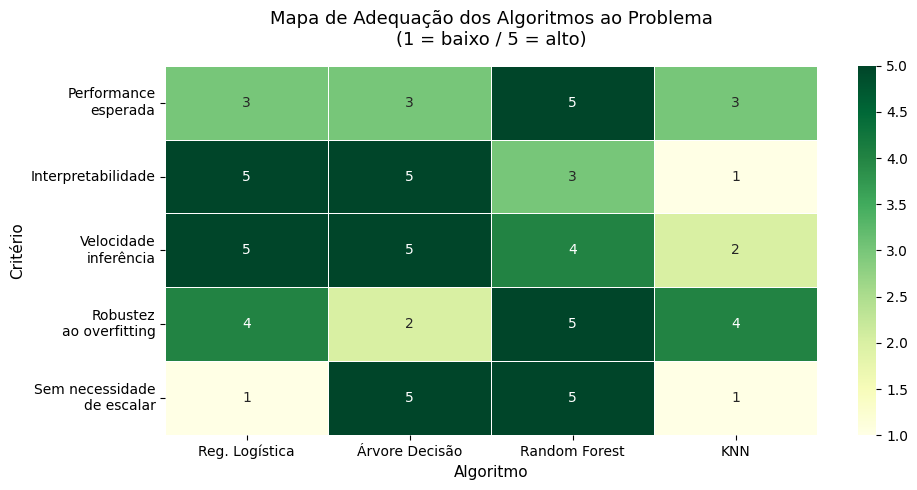

Gráfico salvo em: reports/adequacao_algoritmos.png


In [7]:
# Gráfico radar / heatmap de adequação de cada algoritmo por critério
criterios_radar = ['Performance\nesperada', 'Interpretabilidade', 'Velocidade\ninferência', 'Robustez\nao overfitting', 'Sem necessidade\nde escalar']

scores = pd.DataFrame({
    'Reg. Logística':  [3, 5, 5, 4, 1],
    'Árvore Decisão':  [3, 5, 5, 2, 5],
    'Random Forest':   [5, 3, 4, 5, 5],
    'KNN':             [3, 1, 2, 4, 1],
}, index=criterios_radar)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    scores,
    annot=True, fmt='d',
    cmap='YlGn',
    vmin=1, vmax=5,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Mapa de Adequação dos Algoritmos ao Problema\n(1 = baixo / 5 = alto)', fontsize=13, pad=15)
ax.set_xlabel('Algoritmo', fontsize=11)
ax.set_ylabel('Critério', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/adequacao_algoritmos.png', dpi=150, bbox_inches='tight')
plt.show()

print("Gráfico salvo em: reports/adequacao_algoritmos.png")

### Leitura do mapa de adequação

- **Random Forest** se destaca em performance esperada e robustez ao overfitting — principal candidato.
- **Árvore de Decisão** brilha em interpretabilidade e velocidade — importante para validação clínica das regras aprendidas.
- **Regressão Logística** é o melhor em interpretabilidade linear e velocidade — excelente baseline.
- **KNN** fica atrás nos critérios mais relevantes para o problema (interpretabilidade e velocidade de inferência).

A escolha final do modelo será feita no **notebook 05_treinamento.ipynb** com base nos resultados reais de validação, comparados contra esta hipótese.

---
## 6. Definição do Protocolo de Decisão Final

Para garantir objetividade na escolha do modelo vencedor no notebook de treinamento (05), o protocolo abaixo será seguido:

| Critério | Threshold mínimo aceitável | Eliminação |
|---|---|---|
| Recall macro (validação) | ≥ 0.80 | Modelo abaixo disso é descartado |
| F1-score macro (validação) | ≥ 0.78 | Critério de qualidade geral |
| Accuracy (validação) | ≥ 0.80 | Referência (dataset balanceado) |
| Overfitting | Recall treino - Recall val ≤ 0.10 | Gap > 10pp indica overfitting |

**Modelo vencedor:** aquele com maior Recall macro na validação, dentre os que passam todos os thresholds.

**Modelos para tuning (notebook 06):** os 2 melhores em Recall macro serão levados para GridSearchCV.

---
## Checklist — Etapa 2.4

- [x] `04_escolha_modelo.ipynb` criado e executado
- [x] Pelo menos 4 algoritmos candidatos analisados com vantagens e desvantagens
- [x] Critério de avaliação definido ANTES de treinar (Recall macro como métrica principal)
- [x] Hipótese inicial documentada sobre qual algoritmo deve performar melhor (Random Forest)
- [x] Justificativa de por que cada algoritmo é ou não adequado ao problema de pneumonia